In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [ ]:
hek_airna_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver121224_mergedref_ON0090_m6Afinal/pileup_strid.npz.genomic.pkl"
hek_airna_df = pd.read_pickle(hek_airna_df)

In [ ]:
hela_airna_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver121224_mergedref_ON0091_m6Afinal/pileup_strid.npz.genomic.pkl"
hela_airna_df = pd.read_pickle(hela_airna_df)

In [ ]:
hek_label = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/BaeklabFinal.Genome.v2Genomic.GP3.depth5_None.twm6astrict.agg.pkl")
hela_label = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0091/ON0091/label/BaeklabFinal.eTAM..v2Genomic.GP3.depth5_None.twm6astrict.agg.pkl")

In [ ]:
hek_airna_df = hek_airna_df.reset_index(drop=True).merge(hek_label, on="genome_id", how="inner")

In [ ]:
hela_airna_df = hela_airna_df.reset_index(drop=True).merge(hela_label, on="genome_id", how="inner")

In [ ]:
print(hek_airna_df)
print(hela_airna_df)

In [ ]:
def dom_threshold(df):
    return np.log10(0.02)*(df["dom"]) > df["logsum_1_p_pos"]/df["count_all"]

In [ ]:
hek_airna_df["dom_threshold"] = dom_threshold(hek_airna_df)
hela_airna_df["dom_threshold"] = dom_threshold(hela_airna_df)

In [ ]:
hek_dorado_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/reference_test/dorado_output.modkit.bed.m6A.genomic.pkl")

In [ ]:
hela_dorado_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0091/ON0091/result/reference_test/dorado_output.modkit.bed.m6A.genomic.pkl")

In [ ]:
hek_dorado_df = hek_dorado_df.reset_index(drop=True).merge(hek_label, on="genome_id", how="inner")

In [ ]:
hela_dorado_df = hela_dorado_df.reset_index(drop=True).merge(hela_label, on="genome_id", how="inner")

In [ ]:
hek_m6anet_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/m6anet/ON0090/gene_df.pkl")
print(hek_m6anet_df)

In [ ]:
hela_m6anet_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/m6anet/ON0091/gene_df.pkl")
print(hek_m6anet_df)

In [ ]:
hek_m6anet_df = hek_m6anet_df.reset_index(drop=True).merge(hek_label, on="genome_id", how="inner")

In [ ]:
hela_m6anet_df = hela_m6anet_df.reset_index(drop=True).merge(hela_label, on="genome_id", how="inner")

In [ ]:
def get_density(x,y, sample=1000, bw_method= 0.2):
    values = np.stack([x, y], axis=0)
    sampled = values
    sampled = sampled[:, np.random.choice(sampled.shape[1], sample, replace=False)]
    kernel = stats.gaussian_kde(sampled, bw_method=bw_method)
    density = kernel(values)
    density = np.clip(density, None, np.percentile(density[x>0], 99))
    return density

In [ ]:
from scipy import stats

def plot_scatter(df, x = "m6A_level", y = "dom", alpha=0.5, s = 30, noplot = False, bw_method = 0.2, sample = 1000):
    if not noplot:
        density = get_density(df[x], df[y], sample=sample, bw_method=bw_method)
        plt.style.use('default')
        plt.style.use('seaborn-v0_8-white')
        plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})
        fig, ax = plt.subplots(1, 1, figsize=(30, 30))
        sns.scatterplot(x=df[x], y=df[y], ax=ax, c=density,
                        cmap=sns.color_palette("flare_r", as_cmap=True), s=s, legend=False, linewidth=0, alpha = alpha)
        ax.set_xlim(-0.01, 1.01)
        ax.set_ylim(-0.01, 1.01)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticks([])
        ax.set_yticks([])
        plt.show()
    print("R2",    stats.pearsonr(df[x], df[y])[0]**2)
    print("Rho2", stats.spearmanr(df[x], df[y])[0]**2)

In [ ]:

def plot_scatter(axes,r2_table,rho2_table,coord, df, x = "m6A_level", y = "dom", alpha=0.2, s = 10, noplot = False, bw_method = 0.2, sample = 1000):
    ax = axes[coord[0],coord[1]]
    plt.style.use('default')
    plt.style.use('seaborn-v0_8-white')
    sns.scatterplot(x=df[x], y=df[y], ax=ax, c="royalblue", s=s, legend=False, linewidth=0, alpha = alpha)
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.01, 1.01)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    r2 = stats.pearsonr(df[x], df[y])[0]**2
    rho2 = stats.spearmanr(df[x], df[y])[0]**2
    ## plot text in a white box
    ax.text(0.05, 0.95, f"R2: {r2:.3f}\nρ2: {rho2:.3f}", horizontalalignment='left', verticalalignment='top', transform=ax.transAxes, fontsize=24, bbox=dict(facecolor='white', alpha=0.5))
    r2_table[coord[0],coord[1]] = r2
    rho2_table[coord[0],coord[1]] = rho2
    return None

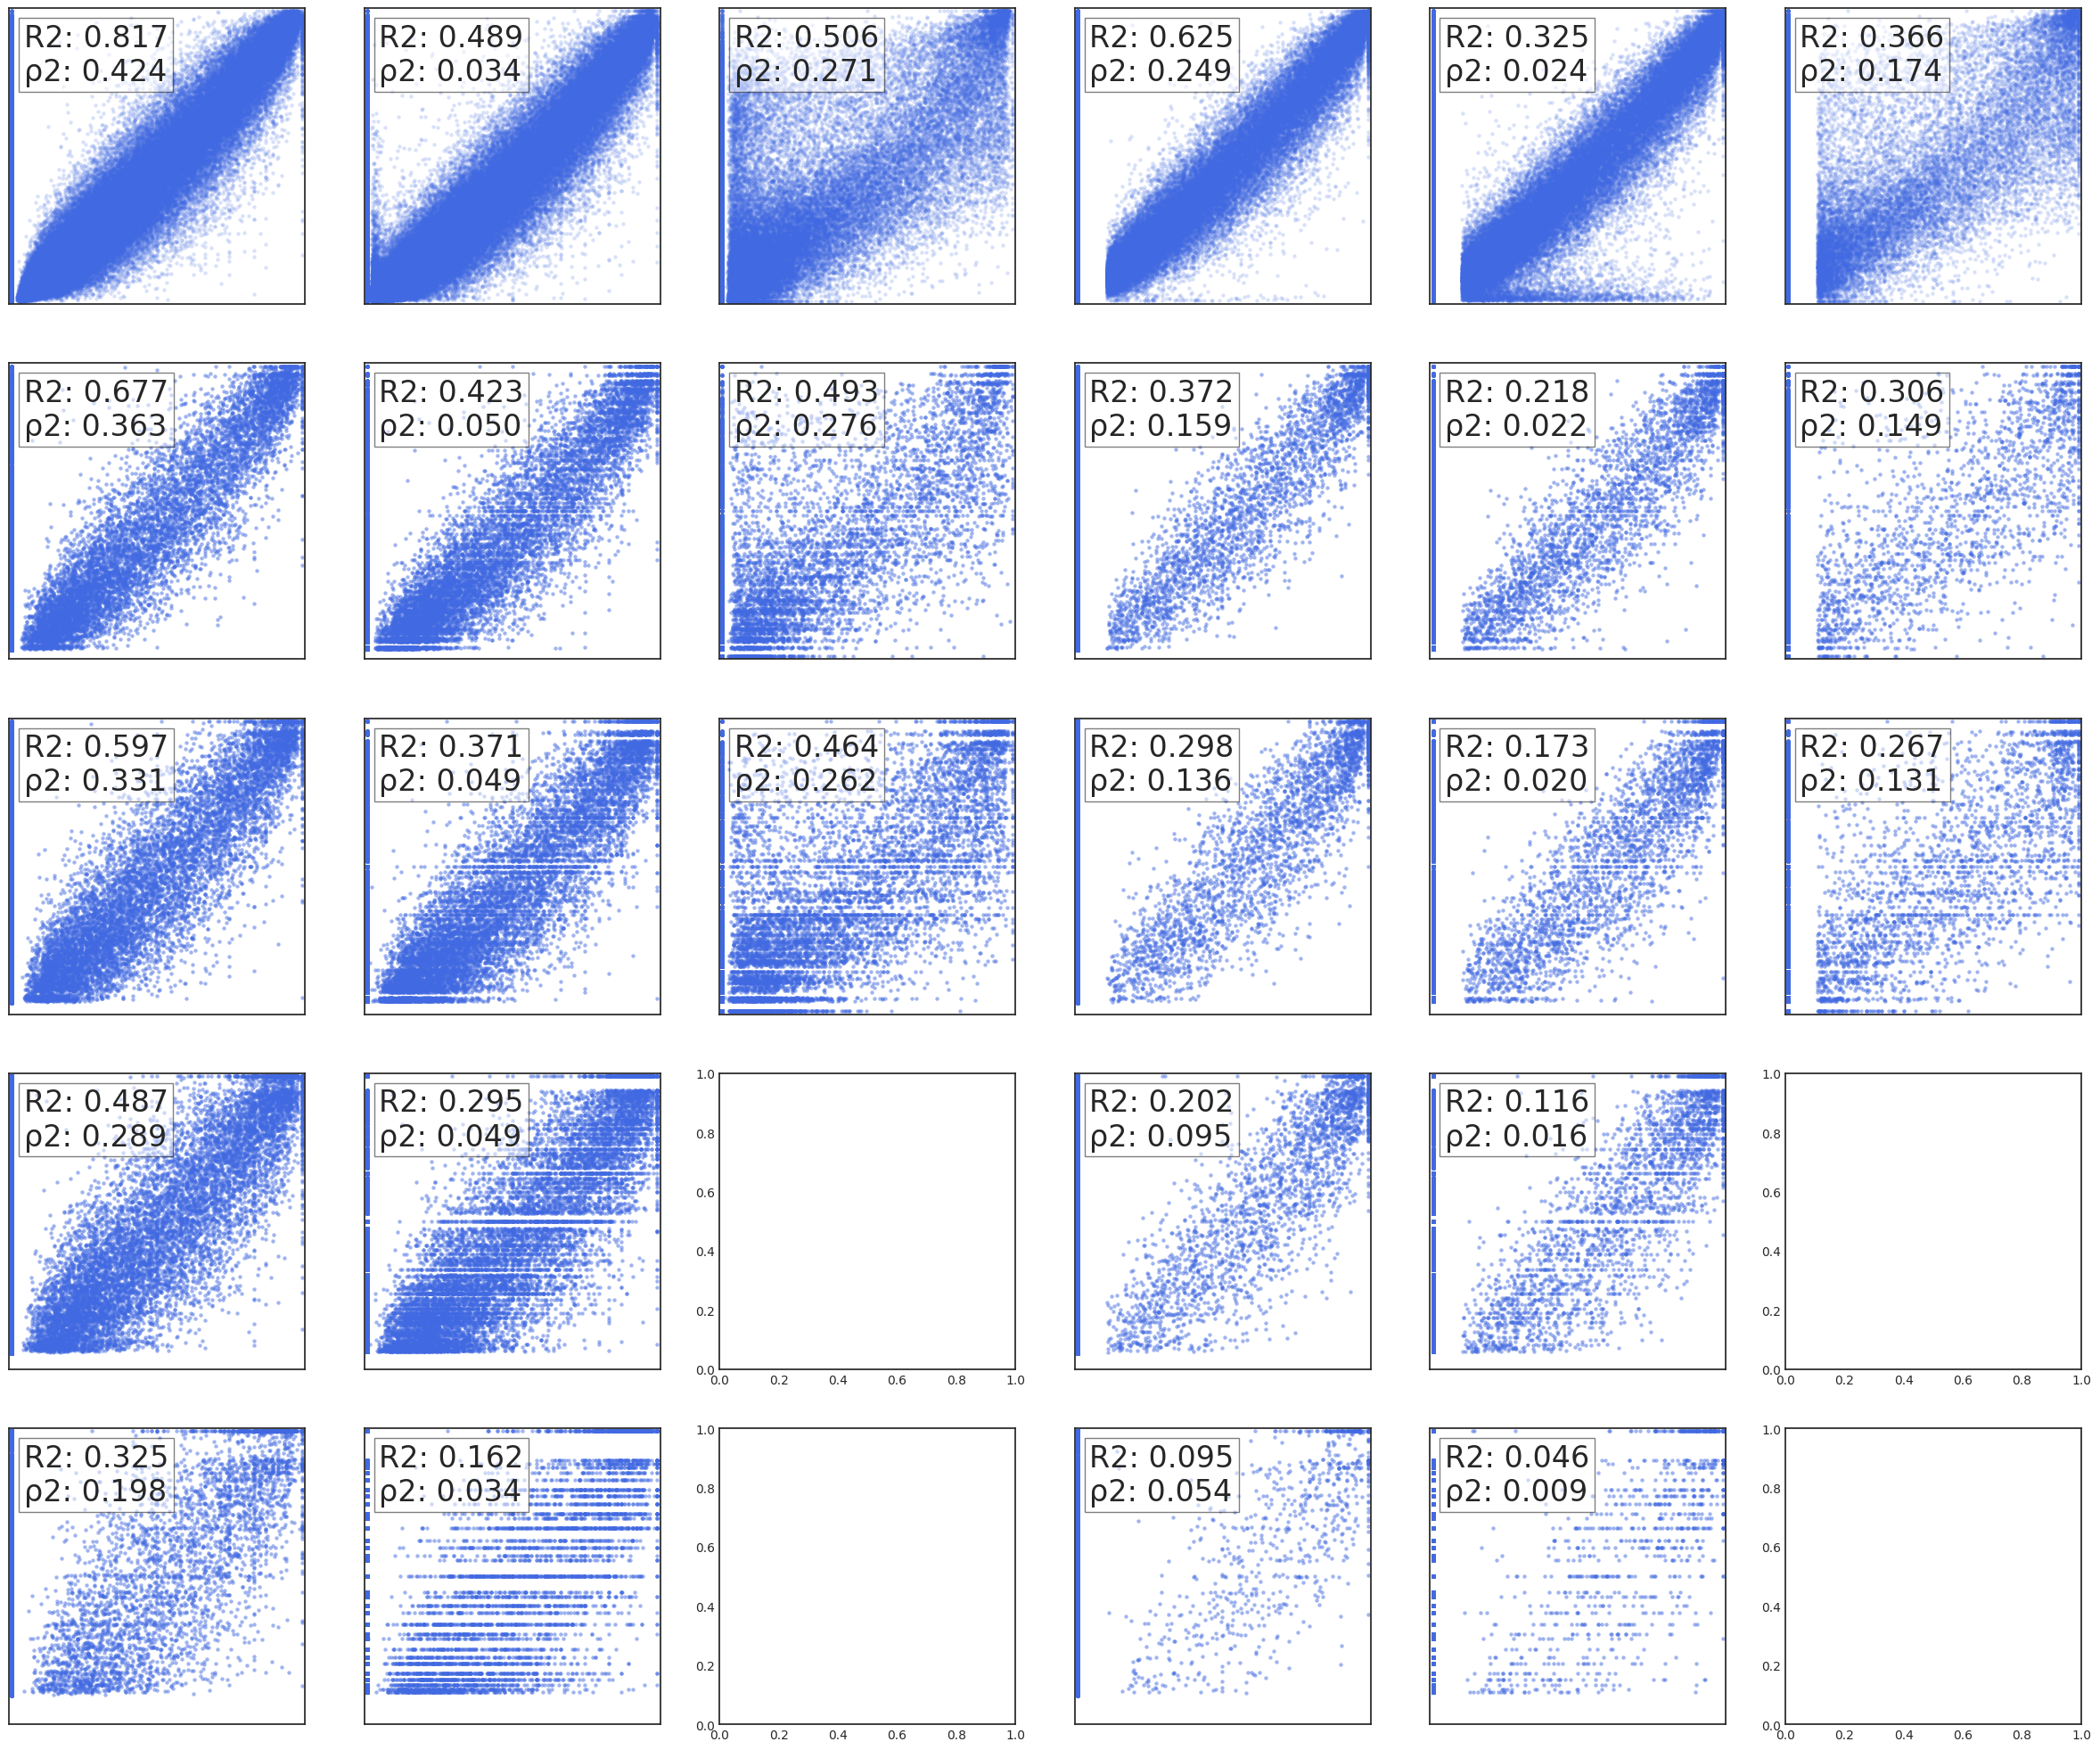

In [67]:
fig, axes = plt.subplots(5, 6, figsize=(30, 25))
df = hela_airna_df
r2_table = np.zeros((5,6))
rho2_table = np.zeros((5,6))
plot_scatter(axes,r2_table,rho2_table,[0,3],df[df["dom_threshold"] & (df["count_all"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,3],df[df["dom_threshold"] & (df["count_all"] > 30) & (df["count_all"] <= 40)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,3],df[df["dom_threshold"] & (df["count_all"] > 20) & (df["count_all"] <= 30)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[3,3],df[df["dom_threshold"] & (df["count_all"] > 10) & (df["count_all"] <= 20)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[4,3],df[df["dom_threshold"] & (df["count_all"] > 5) & (df["count_all"] <= 10)],  alpha = 0.5)

df = hek_airna_df
plot_scatter(axes,r2_table,rho2_table,[0,0],df[df["dom_threshold"] & (df["count_all"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,0],df[df["dom_threshold"] & (df["count_all"] > 30) & (df["count_all"] <= 40)],alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,0],df[df["dom_threshold"] & (df["count_all"] > 20) & (df["count_all"] <= 30)],alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[3,0],df[df["dom_threshold"] & (df["count_all"] > 10) & (df["count_all"] <= 20)],alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[4,0],df[df["dom_threshold"] & (df["count_all"] > 5) & (df["count_all"] <= 10)], alpha = 0.5)

df = hek_m6anet_df
plot_scatter(axes,r2_table,rho2_table,[0,2],df[(df["pm6a"] > 0) & (df["count_dom"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,2],df[(df["pm6a"] > 0) & (df["count_dom"] > 30) & (df["count_dom"] <= 40)],alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,2],df[(df["pm6a"] > 0) & (df["count_dom"] > 20) & (df["count_dom"] <= 30)],alpha = 0.5)

df = hela_m6anet_df
plot_scatter(axes,r2_table,rho2_table,[0,5],df[(df["pm6a"] > 0) & (df["count_dom"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,5],df[(df["pm6a"] > 0) & (df["count_dom"] > 30) & (df["count_dom"] <= 40)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,5],df[(df["pm6a"] > 0) & (df["count_dom"] > 20) & (df["count_dom"] <= 30)], alpha = 0.5)

df = hek_dorado_df
plot_scatter(axes,r2_table,rho2_table,[0,1],df[(df["dom"] > 0) & (df["count_dom"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,1],df[(df["dom"] > 0) & (df["count_dom"] > 30) & (df["count_dom"] <= 40)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,1],df[(df["dom"] > 0) & (df["count_dom"] > 20) & (df["count_dom"] <= 30)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[3,1],df[(df["dom"] > 0) & (df["count_dom"] > 10) & (df["count_dom"] <= 20)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[4,1],df[(df["dom"] > 0) & (df["count_dom"] >= 5) & (df["count_dom"] <= 10)], alpha = 0.5)

df = hela_dorado_df
plot_scatter(axes,r2_table,rho2_table,[0,4],df[(df["dom"] > 0) & (df["count_dom"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,4],df[(df["dom"] > 0) & (df["count_dom"] > 30) & (df["count_dom"] <= 40)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,4],df[(df["dom"] > 0) & (df["count_dom"] > 20) & (df["count_dom"] <= 30)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[3,4],df[(df["dom"] > 0) & (df["count_dom"] > 10) & (df["count_dom"] <= 20)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[4,4],df[(df["dom"] > 0) & (df["count_dom"] >= 5) & (df["count_dom"] <= 10)], alpha = 0.5)

In [68]:
r2_table

array([[0.8165209 , 0.48890453, 0.50568208, 0.62506759, 0.32485193,
        0.36580379],
       [0.6767514 , 0.42311366, 0.49306026, 0.37213865, 0.21796886,
        0.30623502],
       [0.59668915, 0.37115239, 0.46400833, 0.29762148, 0.17296872,
        0.26680187],
       [0.48729662, 0.29470105, 0.        , 0.20236357, 0.11629861,
        0.        ],
       [0.32467978, 0.16219956, 0.        , 0.09480545, 0.04556898,
        0.        ]])

In [69]:
rho2_table

array([[0.42410277, 0.03376526, 0.27129021, 0.24919345, 0.02391966,
        0.17402253],
       [0.36296629, 0.05020983, 0.27641795, 0.15899659, 0.02168027,
        0.14852017],
       [0.33121484, 0.04948548, 0.26187818, 0.13584288, 0.01965953,
        0.13108737],
       [0.28871855, 0.04867042, 0.        , 0.09537237, 0.01566137,
        0.        ],
       [0.19829311, 0.03361003, 0.        , 0.05417727, 0.00876757,
        0.        ]])

In [70]:
hek_depth_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/reference_test/dorado_output.pileup.label.pkl.genomic.pkl")
hela_depth_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0091/ON0091/result/reference_test/dorado_output.pileup.label.pkl.genomic.pkl")

In [72]:
hek_depth_df = hek_depth_df.reset_index(drop=True)[["genome_id", "depth"]]
hela_depth_df = hela_depth_df.reset_index(drop=True)[["genome_id", "depth"]]


In [73]:
hek_airna_df = hek_airna_df.reset_index(drop=True).merge(hek_depth_df, on="genome_id", how="left")
hela_airna_df = hela_airna_df.reset_index(drop=True).merge(hela_depth_df, on="genome_id", how="left")
hek_m6anet_df = hek_m6anet_df.reset_index(drop=True).merge(hek_depth_df, on="genome_id", how="left")
hela_m6anet_df = hela_m6anet_df.reset_index(drop=True).merge(hela_depth_df, on="genome_id", how="left")
hek_dorado_df = hek_dorado_df.reset_index(drop=True).merge(hek_depth_df, on="genome_id", how="left")
hela_dorado_df = hela_dorado_df.reset_index(drop=True).merge(hela_depth_df, on="genome_id", how="left")

KeyError: 'depth'

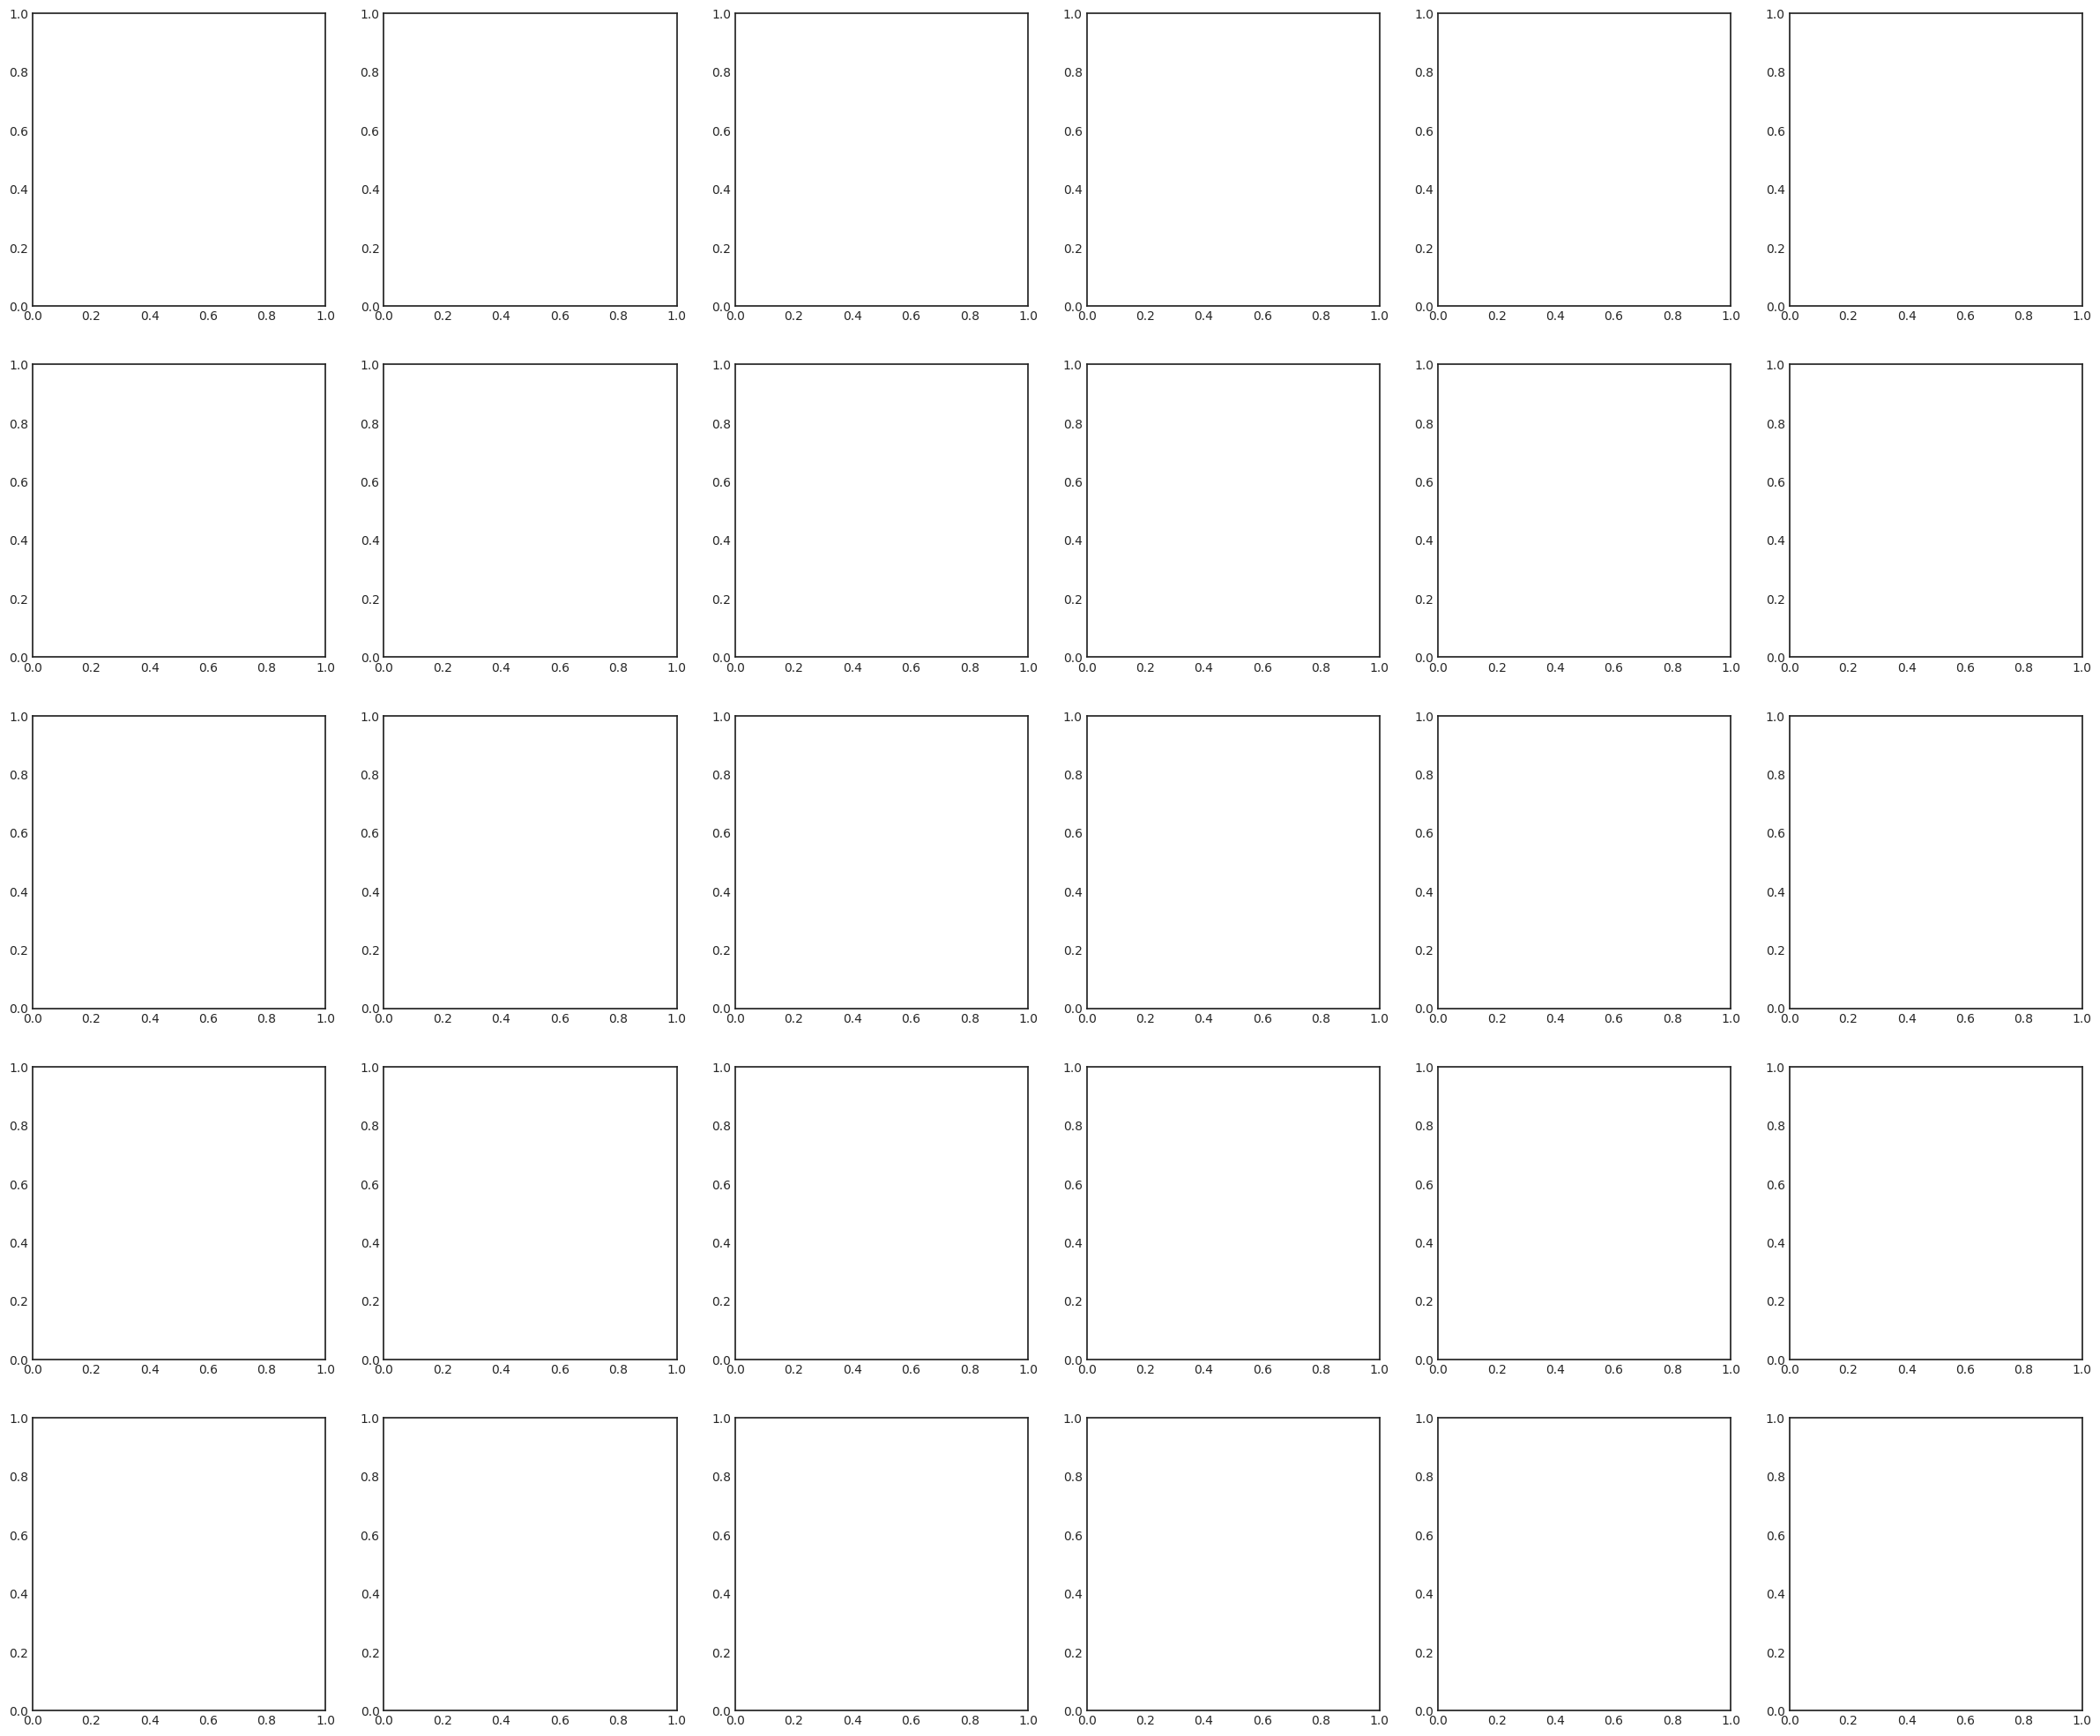

In [74]:
fig, axes = plt.subplots(5, 6, figsize=(30, 25))
r2_table = np.zeros((5,6))
rho2_table = np.zeros((5,6))


df = hela_airna_df
plot_scatter(axes,r2_table,rho2_table,[0,3],df[df["dom_threshold"] & (df["depth"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,3],df[df["dom_threshold"] & (df["depth"] > 30) & (df["depth"] <= 40)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,3],df[df["dom_threshold"] & (df["depth"] > 20) & (df["depth"] <= 30)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[3,3],df[df["dom_threshold"] & (df["depth"] > 10) & (df["depth"] <= 20)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[4,3],df[df["dom_threshold"] & (df["depth"] > 5) &  (df["depth"] <= 10)], alpha = 0.5)

df = hek_airna_df
plot_scatter(axes,r2_table,rho2_table,[0,0],df[df["dom_threshold"] & (df["depth"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,0],df[df["dom_threshold"] & (df["depth"] > 30) & (df["depth"] <= 40)],alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,0],df[df["dom_threshold"] & (df["depth"] > 20) & (df["depth"] <= 30)],alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[3,0],df[df["dom_threshold"] & (df["depth"] > 10) & (df["depth"] <= 20)],alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[4,0],df[df["dom_threshold"] & (df["depth"] > 5) &  (df["depth"] <= 10)],alpha = 0.5)

df = hek_m6anet_df
plot_scatter(axes,r2_table,rho2_table,[0,2],df[(df["pm6a"] > 0) & (df["depth"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,2],df[(df["pm6a"] > 0) & (df["depth"] > 30) & (df["depth"] <= 40)],alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,2],df[(df["pm6a"] > 0) & (df["depth"] > 20) & (df["depth"] <= 30)],alpha = 0.5)

df = hela_m6anet_df
plot_scatter(axes,r2_table,rho2_table,[0,5],df[(df["pm6a"] > 0) & (df["depth"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,5],df[(df["pm6a"] > 0) & (df["depth"] > 30) & (df["depth"] <= 40)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,5],df[(df["pm6a"] > 0) & (df["depth"] > 20) & (df["depth"] <= 30)], alpha = 0.5)

df = hek_dorado_df
plot_scatter(axes,r2_table,rho2_table,[0,1],df[(df["dom"] > 0) & (df["depth"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,1],df[(df["dom"] > 0) & (df["depth"] > 30) & (df["depth"] <= 40)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,1],df[(df["dom"] > 0) & (df["depth"] > 20) & (df["depth"] <= 30)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[3,1],df[(df["dom"] > 0) & (df["depth"] > 10) & (df["depth"] <= 20)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[4,1],df[(df["dom"] > 0) & (df["depth"] >= 5) & (df["depth"] <= 10)], alpha = 0.5)

df = hela_dorado_df
df = df[df["exp_depth"] >= 20]
plot_scatter(axes,r2_table,rho2_table,[0,4],df[(df["dom"] > 0) & (df["depth"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,4],df[(df["dom"] > 0) & (df["depth"] > 30) & (df["depth"] <= 40)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,4],df[(df["dom"] > 0) & (df["depth"] > 20) & (df["depth"] <= 30)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[3,4],df[(df["dom"] > 0) & (df["depth"] > 10) & (df["depth"] <= 20)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[4,4],df[(df["dom"] > 0) & (df["depth"] >= 5) & (df["depth"] <= 10)], alpha = 0.5)